# Sonic Universe — Track Clustering & Interactive Map

**Goal:** Reduce 7-dimensional audio feature space to 2D/3D using UMAP, cluster tracks with K-Means, and render an interactive universe where every track is a star.

---

## Table of Contents
1. [Setup & Load Data](#1)
2. [Feature Scaling](#2)
3. [Elbow Method — Choose K](#3)
4. [K-Means Clustering](#4)
5. [UMAP Dimensionality Reduction](#5)
6. [Cluster Profiles](#6)
7. [The Universe — Interactive Map](#7)
8. [Export](#8)

---
## 1. Setup & Load Data <a id='1'></a>

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap
import plotly.graph_objects as go
import plotly.express as px

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

BASE_DIR   = Path().resolve()
if BASE_DIR.name == "notebooks": BASE_DIR = BASE_DIR.parent
OUTPUT_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SPACE_BG   = "#0a0a1a"
SPACE_GRID = "#1a1a3a"

AUDIO_FEATURES = [
    "acousticness", "danceability", "energy",
    "instrumentalness", "liveness", "speechiness", "valence",
]

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
print("Libraries loaded.")

Libraries loaded.


In [3]:
df = pd.read_csv(OUTPUT_DIR / 'alltime_top_songs_with_features.csv')
df = df[df['energy'].notna()].copy()
df.reset_index(drop=True, inplace=True)
print(f'Songs with audio features: {len(df):,}')
df[['track_name', 'artist_name', 'total_plays', 'genre'] + AUDIO_FEATURES].head()

Songs with audio features: 724


,track_name,artist_name,total_plays,genre,acousticness,danceability,energy,instrumentalness,liveness,speechiness,valence
0,Last Nite,The Strokes,374,Children’s Music,0.0223,0.624,0.899,0.000155,0.0975,0.0295,0.797
1,Star Treatment,Arctic Monkeys,372,Indie,0.2430,0.581,0.767,0.001310,0.1410,0.0527,0.673
2,Leave It In My Dreams,The Voidz,316,Alternative,0.0226,0.600,0.746,0.011900,0.1090,0.0355,0.614
3,Soledad y el Mar (feat. Los Macorinos),Natalia Lafourcade,300,Rock,0.8960,0.726,0.177,0.000002,0.1160,0.0353,0.618
4,Someday,The Growlers,293,Indie,0.9530,0.402,0.772,0.860000,0.1720,0.0394,0.748


---
## 2. Feature Scaling <a id='2'></a>

In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[AUDIO_FEATURES].values)
print('Feature matrix shape:', X_scaled.shape)
pd.DataFrame(X_scaled, columns=AUDIO_FEATURES).describe().T[['mean','std','min','max']].round(3)

Feature matrix shape: (724, 7)


,mean,std,min,max
acousticness,0.0,1.001,-0.890,2.694
danceability,-0.0,1.001,-3.503,2.758
energy,-0.0,1.001,-3.024,1.684
instrumentalness,0.0,1.001,-0.410,3.921
liveness,0.0,1.001,-1.144,6.444
speechiness,0.0,1.001,-0.564,9.058
valence,-0.0,1.001,-2.345,1.695


---
## 3. Elbow Method — Choose K <a id='3'></a>

  K= 2  inertia=    4094.3  silhouette=0.2282
  K= 3  inertia=    3585.1  silhouette=0.2007
  K= 4  inertia=    3025.0  silhouette=0.2612
  K= 5  inertia=    2631.3  silhouette=0.2209
  K= 6  inertia=    2353.2  silhouette=0.2199
  K= 7  inertia=    2163.2  silhouette=0.2080
  K= 8  inertia=    2019.6  silhouette=0.2026
  K= 9  inertia=    1919.2  silhouette=0.1977
  K=10  inertia=    1834.7  silhouette=0.1895
  K=11  inertia=    1744.9  silhouette=0.1905
  K=12  inertia=    1674.9  silhouette=0.1858
  K=13  inertia=    1618.3  silhouette=0.1819
  K=14  inertia=    1572.2  silhouette=0.1830


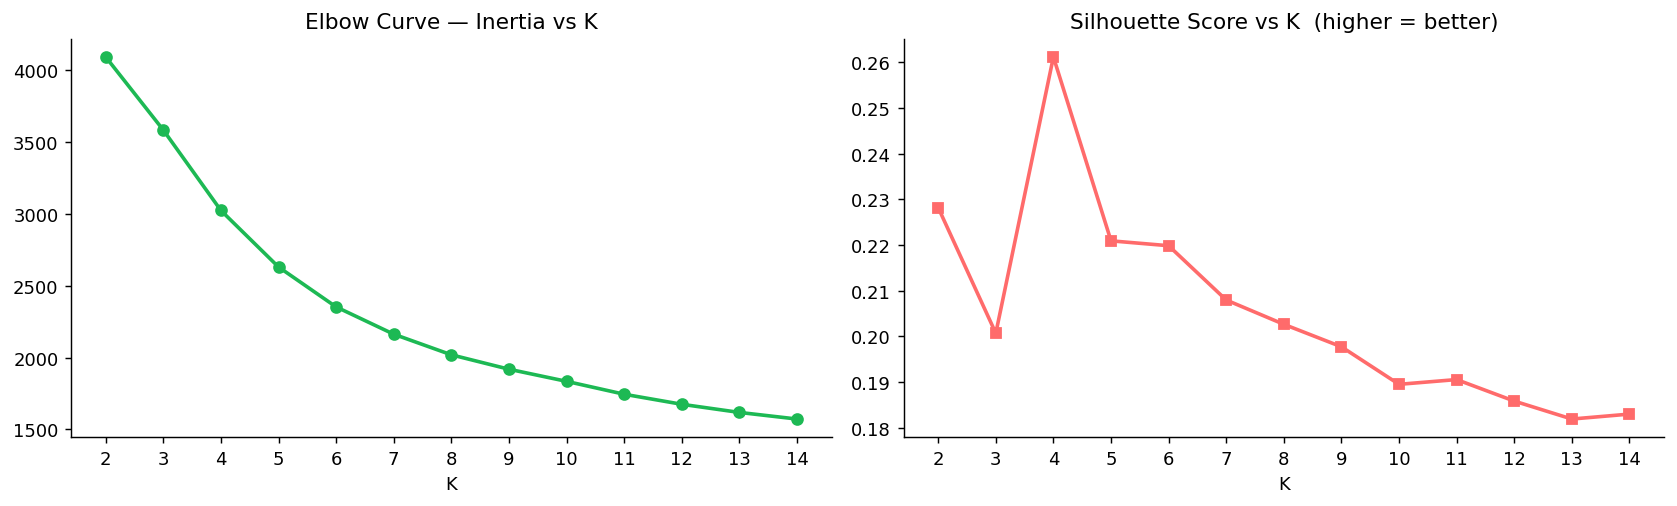

Best silhouette at K=4


In [5]:
K_RANGE     = range(2, 15)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=min(2000, len(X_scaled))))
    print(f'  K={k:>2}  inertia={km.inertia_:>10.1f}  silhouette={silhouettes[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#1DB954', linewidth=2)
axes[0].set_title('Elbow Curve — Inertia vs K'); axes[0].set_xlabel('K'); axes[0].set_xticks(list(K_RANGE))
axes[1].plot(list(K_RANGE), silhouettes, 's-', color='#FF6B6B', linewidth=2)
axes[1].set_title('Silhouette Score vs K  (higher = better)'); axes[1].set_xlabel('K'); axes[1].set_xticks(list(K_RANGE))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_elbow.png', bbox_inches='tight')
plt.show()

best_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f'Best silhouette at K={best_k}')

---
## 4. K-Means Clustering <a id='4'></a>

Override `K_FINAL` below if you prefer a different value after inspecting the elbow chart.

In [6]:
K_FINAL = best_k   # change if desired, e.g. K_FINAL = 7

km_final      = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print(f'K_FINAL = {K_FINAL}')
print(f'Silhouette: {silhouette_score(X_scaled, df["cluster"]):.4f}')
print(df.groupby('cluster').size().reset_index(name='tracks').to_string(index=False))

K_FINAL = 4
Silhouette: 0.2612
 cluster  tracks
       0     410
       1     214
       2      70
       3      30


---
## 5. UMAP Dimensionality Reduction <a id='5'></a>

In [7]:
print('Running UMAP 2D...')
e2 = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.1, random_state=42).fit_transform(X_scaled)
df['umap_x'], df['umap_y'] = e2[:,0], e2[:,1]

print('Running UMAP 3D...')
e3 = umap.UMAP(n_components=3, n_neighbors=20, min_dist=0.1, random_state=42).fit_transform(X_scaled)
df['umap_x3'], df['umap_y3'], df['umap_z3'] = e3[:,0], e3[:,1], e3[:,2]
print('Done.')

Running UMAP 2D...
Running UMAP 3D...
Done.


---
## 6. Cluster Profiles <a id='6'></a>

In [8]:
profiles = df.groupby('cluster')[AUDIO_FEATURES + ['total_plays']].mean().round(3)
profiles['track_count'] = df.groupby('cluster').size()
print(profiles.to_string())

         acousticness  danceability  energy  instrumentalness  liveness  speechiness  valence  total_plays  track_count
cluster                                                                                                                
0               0.104         0.585   0.751             0.019     0.179        0.051    0.681       55.207          410
1               0.503         0.557   0.421             0.033     0.147        0.044    0.421       51.743          214
2               0.255         0.476   0.693             0.701     0.199        0.045    0.566       71.743           70
3               0.279         0.682   0.616             0.010     0.195        0.320    0.474       47.767           30


ValueError: 'rgb(127, 60, 141)' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

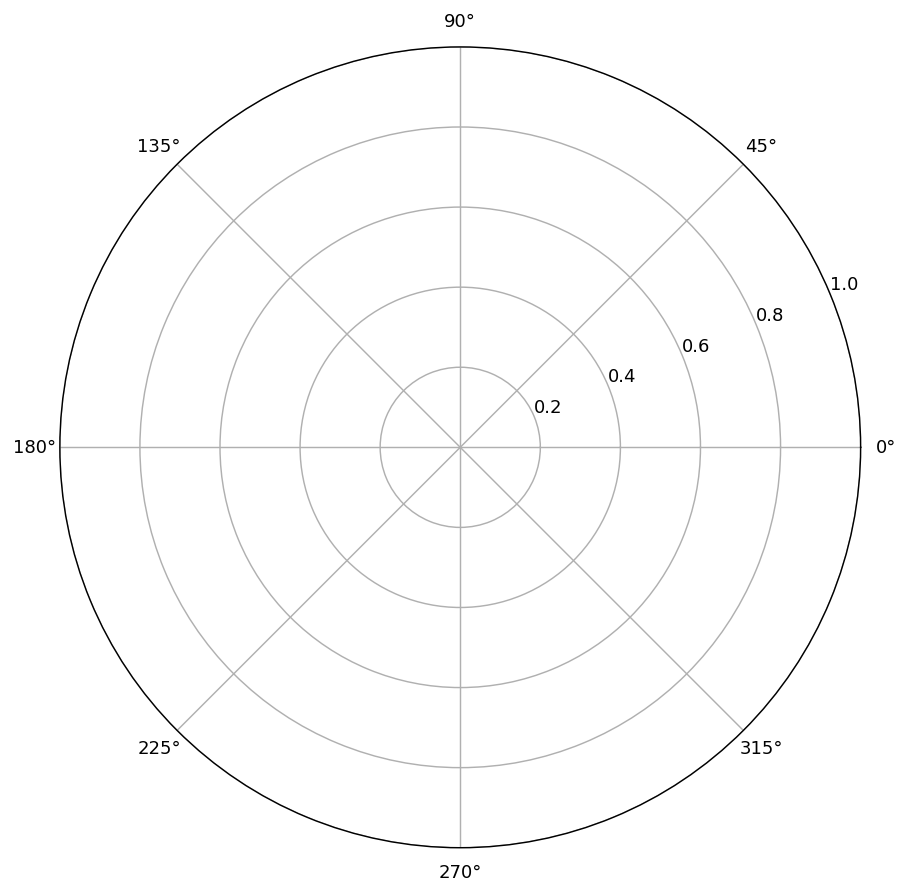

In [10]:
# Radar chart
N      = len(AUDIO_FEATURES)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
CLUSTER_COLORS = px.colors.qualitative.Bold

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
patches = []
for cid, row in profiles[AUDIO_FEATURES].iterrows():
    values = row.tolist() + [row.iloc[0]]
    color  = CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
    ax.plot(angles, values, linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.10, color=color)
    patches.append(mpatches.Patch(color=color, label=f'Cluster {cid} ({profiles.loc[cid,"track_count"]} tracks)'))
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.capitalize() for f in AUDIO_FEATURES], fontsize=10)
ax.set_ylim(0,1)
ax.set_title('Cluster Audio Profiles', pad=25, fontweight='bold')
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.45,1.15), fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_cluster_radar.png', bbox_inches='tight')
plt.show()

In [11]:
print('Top 5 tracks per cluster (by total plays)\n')
for cid in sorted(df['cluster'].unique()):
    grp = df[df['cluster']==cid].nlargest(5,'total_plays')
    print(f'── Cluster {cid} ─────────────────────────────────────────')
    for _, r in grp.iterrows():
        print(f"  {r['track_name'][:40]:<42} {r['artist_name'][:28]:<30} {int(r['total_plays']):>5} plays")
    print()

Top 5 tracks per cluster (by total plays)

── Cluster 0 ─────────────────────────────────────────
  Last Nite                                  The Strokes                      374 plays
  Star Treatment                             Arctic Monkeys                   372 plays
  Leave It In My Dreams                      The Voidz                        316 plays
  One Point Perspective                      Arctic Monkeys                   250 plays
  Someday                                    The Strokes                      249 plays

── Cluster 1 ─────────────────────────────────────────
  Soledad y el Mar (feat. Los Macorinos)     Natalia Lafourcade               300 plays
  The Waiting                                Angel Olsen                      287 plays
  Do I Wanna Know?                           Arctic Monkeys                   238 plays
  Clouds                                     BØRNS                            234 plays
  The Ultracheese                            Arctic Mo

In [12]:
# ── Cluster Personalities ────────────────────────────────────────────
# For each cluster, show which audio features are notably above or below
# your overall library average, using z-scores.

overall_mean  = df[AUDIO_FEATURES].mean()
overall_std   = df[AUDIO_FEATURES].std().replace(0, 1e-9)
cluster_means = df.groupby('cluster')[AUDIO_FEATURES].mean()

THRESHOLD = 0.55   # z-score cutoff for 'notably different'

print('── Cluster Personalities ──────────────────────────────────────────\n')
print(f'  (compared to your library average across {len(df):,} tracks)\n')

for cid, row in cluster_means.iterrows():
    n     = len(df[df['cluster'] == cid])
    z     = (row - overall_mean) / overall_std
    highs = [f for f in AUDIO_FEATURES if z[f] >  THRESHOLD]
    lows  = [f for f in AUDIO_FEATURES if z[f] < -THRESHOLD]

    traits = []
    if highs: traits.append('↑ High:  ' + ', '.join(highs))
    if lows:  traits.append('↓ Low:   ' + ', '.join(lows))
    personality = '  |  '.join(traits) if traits else 'Balanced — no feature stands out strongly'

    print(f'Cluster {cid}  ({n} tracks)')
    print(f'  {personality}')
    print()
    for feat in AUDIO_FEATURES:
        if abs(z[feat]) < 0.3:
            continue
        bar_len = min(int(abs(z[feat]) * 4), 12)
        bar     = ('█' * bar_len).ljust(12)
        sign    = '+' if z[feat] > 0 else '-'
        print(f'    {feat:<20} {sign}{bar}  cluster={row[feat]:.2f}  library={overall_mean[feat]:.2f}')
    print()

── Cluster Personalities ──────────────────────────────────────────

  (compared to your library average across 724 tracks)

Cluster 0  (410 tracks)
  Balanced — no feature stands out strongly

    acousticness         -██            cluster=0.10  library=0.24
    energy               +██            cluster=0.75  library=0.64
    instrumentalness     -█             cluster=0.02  library=0.09
    valence              +█             cluster=0.68  library=0.58

Cluster 1  (214 tracks)
  ↑ High:  acousticness  |  ↓ Low:   energy, valence

    acousticness         +███           cluster=0.50  library=0.24
    energy               -████          cluster=0.42  library=0.64
    valence              -██            cluster=0.42  library=0.58

Cluster 2  (70 tracks)
  ↑ High:  instrumentalness  |  ↓ Low:   danceability

    danceability         -██            cluster=0.48  library=0.57
    instrumentalness     +███████████   cluster=0.70  library=0.09

Cluster 3  (30 tracks)
  ↑ High:  danceabili

In [13]:
# ── Interactive Cluster Feature Heatmap ──────────────────────────────
# Each cell = how far that feature deviates from YOUR library average.
# Red = above avg, Blue = below avg. Hover a cell for exact values.

overall_mean  = df[AUDIO_FEATURES].mean()
overall_std   = df[AUDIO_FEATURES].std().replace(0, 1e-9)
cluster_means = df.groupby('cluster')[AUDIO_FEATURES].mean()
z_df          = (cluster_means - overall_mean) / overall_std

THRESHOLD = 0.55
cluster_labels = {}
for cid, row in z_df.iterrows():
    highs = [f for f in AUDIO_FEATURES if row[f] >  THRESHOLD]
    lows  = [f for f in AUDIO_FEATURES if row[f] < -THRESHOLD]
    parts = []
    if highs: parts.append('\u2191 ' + ', '.join(highs))
    if lows:  parts.append('\u2193 ' + ', '.join(lows))
    cluster_labels[cid] = ' | '.join(parts) if parts else 'Balanced'

# Hover text: cluster value vs library average per cell
hover_text = [
    [f'<b>{feat}</b><br>'
     f'Cluster {cid}: {cluster_means.loc[cid, feat]:.2f}<br>'
     f'Library avg: {overall_mean[feat]:.2f}<br>'
     f'z-score: {z_df.loc[cid, feat]:+.2f}'
     for cid in z_df.index]
    for feat in AUDIO_FEATURES
]

fig_heat = go.Figure(go.Heatmap(
    z=z_df.values.T,
    x=[f'Cluster {cid}' for cid in z_df.index],
    y=AUDIO_FEATURES,
    colorscale=[[0.0,'#1a3a8b'],[0.35,'#1e2a5e'],[0.5,'#0a0a1e'],[0.65,'#6b1a1a'],[1.0,'#cc2222']],
    zmid=0, zmin=-2.5, zmax=2.5,
    text=cluster_means.values.T.round(2),
    texttemplate='<b>%{text}</b>',
    hovertext=hover_text,
    hovertemplate='%{hovertext}<extra></extra>',
    colorbar=dict(
        title=dict(text='\u2190 below avg  |  above avg \u2192',
                   font=dict(color='#cccccc', size=11)),
        tickfont=dict(color='#cccccc'),
        tickvals=[-2, -1, 0, 1, 2],
        ticktext=['-2\u03c3', '-1\u03c3', 'avg', '+1\u03c3', '+2\u03c3'],
    ),
))

# Personality labels as x-axis tick annotations
fig_heat.update_xaxes(
    tickvals=list(range(len(z_df))),
    ticktext=[f'<b>Cluster {cid}</b><br><i>{cluster_labels[cid]}</i>' for cid in z_df.index],
    tickfont=dict(size=11, color='#cccccc'),
    showgrid=False,
)
fig_heat.update_yaxes(tickfont=dict(size=11, color='#cccccc'), showgrid=False)

fig_heat.update_layout(
    title=dict(text='What defines each cluster?  (deviation from your library average)',
               font=dict(size=17, color='white'), x=0.5),
    paper_bgcolor=SPACE_BG, plot_bgcolor=SPACE_BG,
    font=dict(color='#cccccc'),
    width=980, height=520,
    margin=dict(l=130, r=20, t=80, b=100),
    hoverlabel=dict(bgcolor='rgba(10,10,30,0.92)', bordercolor='rgba(255,255,255,0.3)',
                    font=dict(size=12, color='white')),
)
fig_heat.show()
print('cluster_labels ready for universe charts.')

cluster_labels ready for universe charts.


---
## 7. The Universe — Interactive Map <a id='7'></a>

| Visual property | Meaning |
|---|---|
| Position | UMAP audio coordinates |
| Colour | Cluster |
| Size | Play count |
| Hover | Track, artist, genre, key features |

Scroll to zoom · drag to pan · hover to inspect.

In [14]:
def make_hover(row):
    genre = row.get('genre','Unknown'); genre = genre if pd.notna(genre) else 'Unknown'
    tempo = row.get('tempo'); tempo_s = f"{tempo:.0f} BPM" if pd.notna(tempo) else '?'
    cid   = int(row['cluster'])
    label = cluster_labels.get(cid, '')
    return (
        f"<b>{row['track_name']}</b><br><i>{row['artist_name']}</i><br>"
        f"Genre: {genre}<br>Plays: {int(row['total_plays'])}<br>"
        f"─────────────────<br>"
        f"Energy: {row['energy']:.2f}  Valence: {row['valence']:.2f}<br>"
        f"Dance:  {row['danceability']:.2f}  Acoust: {row['acousticness']:.2f}<br>"
        f"Tempo: {tempo_s}  Cluster: {cid}<br>"
        f"<i style='color:#aaaaaa'>{label}</i>"
    )

df['hover']   = df.apply(make_hover, axis=1)
plays         = df['total_plays']
df['pt_size'] = (plays - plays.min()) / (plays.max() - plays.min() + 1e-9) * 18 + 4
cluster_ids   = sorted(df['cluster'].unique())
rng           = np.random.default_rng(42)
print('Ready.')

Ready.


In [15]:
# ── 2D Universe ───────────────────────────────────────────────────────
xr = df['umap_x'].max()-df['umap_x'].min(); yr = df['umap_y'].max()-df['umap_y'].min()
x_lo, x_hi = df['umap_x'].min()-xr*.35, df['umap_x'].max()+xr*.35
y_lo, y_hi = df['umap_y'].min()-yr*.35, df['umap_y'].max()+yr*.35

# Three-layer star field: dust, mid stars, bright sparks
n_dust, n_mid, n_bright = 1400, 350, 90
sx_d = rng.uniform(x_lo, x_hi, n_dust);  sy_d = rng.uniform(y_lo, y_hi, n_dust)
sx_m = rng.uniform(x_lo, x_hi, n_mid);   sy_m = rng.uniform(y_lo, y_hi, n_mid)
sx_b = rng.uniform(x_lo, x_hi, n_bright);sy_b = rng.uniform(y_lo, y_hi, n_bright)

fig_2d = go.Figure()

fig_2d.add_trace(go.Scatter(x=sx_d, y=sy_d, mode='markers',
    marker=dict(size=list(rng.uniform(0.4, 1.1, n_dust).round(2)),
                color='rgba(255,255,255,0.07)'),
    hoverinfo='skip', showlegend=False))
fig_2d.add_trace(go.Scatter(x=sx_m, y=sy_m, mode='markers',
    marker=dict(size=list(rng.uniform(0.9, 2.0, n_mid).round(2)),
                color='rgba(210,225,255,0.16)'),
    hoverinfo='skip', showlegend=False))
fig_2d.add_trace(go.Scatter(x=sx_b, y=sy_b, mode='markers',
    marker=dict(size=list(rng.uniform(1.6, 3.2, n_bright).round(2)),
                color='rgba(255,255,255,0.48)'),
    hoverinfo='skip', showlegend=False))

for cid in cluster_ids:
    g = df[df['cluster']==cid]
    fig_2d.add_trace(go.Scatter(
        x=g['umap_x'], y=g['umap_y'], mode='markers', name=f'Cluster {cid}',
        text=g['hover'], hovertemplate='%{text}<extra></extra>',
        marker=dict(size=g['pt_size'], color=CLUSTER_COLORS[cid%len(CLUSTER_COLORS)],
                    opacity=0.83, line=dict(width=0.3, color='rgba(255,255,255,0.35)')),
    ))

fig_2d.update_layout(
    title=dict(text='Your Sonic Universe', font=dict(size=22, color='white'), x=0.5),
    paper_bgcolor=SPACE_BG, plot_bgcolor=SPACE_BG, font=dict(color='#cccccc'),
    legend=dict(bgcolor='rgba(10,10,30,0.7)', bordercolor='rgba(255,255,255,0.2)', borderwidth=1),
    xaxis=dict(showgrid=False, showline=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, showline=False, zeroline=False, showticklabels=False),
    width=1100, height=750, margin=dict(l=20, r=20, t=70, b=20),
    hoverlabel=dict(bgcolor='rgba(10,10,30,0.92)', bordercolor='rgba(255,255,255,0.3)',
                    font=dict(size=12, color='white')),
)
fig_2d.show()

In [16]:
# ── 3D Universe ───────────────────────────────────────────────────────
xr3 = df['umap_x3'].max()-df['umap_x3'].min()
yr3 = df['umap_y3'].max()-df['umap_y3'].min()
zr3 = df['umap_z3'].max()-df['umap_z3'].min()
x_lo3, x_hi3 = df['umap_x3'].min()-xr3*.35, df['umap_x3'].max()+xr3*.35
y_lo3, y_hi3 = df['umap_y3'].min()-yr3*.35, df['umap_y3'].max()+yr3*.35
z_lo3, z_hi3 = df['umap_z3'].min()-zr3*.35, df['umap_z3'].max()+zr3*.35

n3_dust, n3_bright = 1600, 120
sx3_d = rng.uniform(x_lo3, x_hi3, n3_dust)
sy3_d = rng.uniform(y_lo3, y_hi3, n3_dust)
sz3_d = rng.uniform(z_lo3, z_hi3, n3_dust)
sx3_b = rng.uniform(x_lo3, x_hi3, n3_bright)
sy3_b = rng.uniform(y_lo3, y_hi3, n3_bright)
sz3_b = rng.uniform(z_lo3, z_hi3, n3_bright)

fig_3d = go.Figure()

fig_3d.add_trace(go.Scatter3d(x=sx3_d, y=sy3_d, z=sz3_d, mode='markers',
    marker=dict(size=list(rng.uniform(0.3, 0.9, n3_dust).round(2)),
                color='rgba(255,255,255,0.07)'),
    hoverinfo='skip', showlegend=False))
fig_3d.add_trace(go.Scatter3d(x=sx3_b, y=sy3_b, z=sz3_b, mode='markers',
    marker=dict(size=list(rng.uniform(1.0, 2.4, n3_bright).round(2)),
                color='rgba(210,225,255,0.42)'),
    hoverinfo='skip', showlegend=False))

for cid in cluster_ids:
    g = df[df['cluster']==cid]
    fig_3d.add_trace(go.Scatter3d(
        x=g['umap_x3'], y=g['umap_y3'], z=g['umap_z3'],
        mode='markers', name=f'Cluster {cid}',
        text=g['hover'], hovertemplate='%{text}<extra></extra>',
        marker=dict(size=g['pt_size']*0.55, color=CLUSTER_COLORS[cid%len(CLUSTER_COLORS)],
                    opacity=0.85, line=dict(width=0)),
    ))

fig_3d.update_layout(
    title=dict(text='Your Sonic Universe — 3D', font=dict(size=22, color='white'), x=0.5),
    paper_bgcolor=SPACE_BG,
    scene=dict(
        bgcolor=SPACE_BG,
        xaxis=dict(showgrid=False, showbackground=False, showline=False,
                   zeroline=False, showticklabels=False, title=''),
        yaxis=dict(showgrid=False, showbackground=False, showline=False,
                   zeroline=False, showticklabels=False, title=''),
        zaxis=dict(showgrid=False, showbackground=False, showline=False,
                   zeroline=False, showticklabels=False, title=''),
    ),
    font=dict(color='#cccccc'),
    legend=dict(bgcolor='rgba(10,10,30,0.7)', bordercolor='rgba(255,255,255,0.2)', borderwidth=1),
    width=1100, height=800, margin=dict(l=0, r=0, t=70, b=0),
    hoverlabel=dict(bgcolor='rgba(10,10,30,0.92)', bordercolor='rgba(255,255,255,0.3)',
                    font=dict(size=12, color='white')),
)
fig_3d.show()

---
## 8. Export <a id='8'></a>

In [17]:
html_2d = OUTPUT_DIR / 'sonic_universe_2d.html'
html_3d = OUTPUT_DIR / 'sonic_universe_3d.html'

fig_2d.write_html(str(html_2d), include_plotlyjs='cdn', full_html=True)
fig_3d.write_html(str(html_3d), include_plotlyjs='cdn', full_html=True)

out_csv = OUTPUT_DIR / 'top_songs_clustered.csv'
df.drop(columns=['hover','pt_size'], errors='ignore').to_csv(out_csv, index=False)

print(f'2D  ->  {html_2d}  ({html_2d.stat().st_size/1e3:.0f} KB)')
print(f'3D  ->  {html_3d}  ({html_3d.stat().st_size/1e3:.0f} KB)')
print(f'CSV ->  {out_csv}  ({out_csv.stat().st_size/1e3:.0f} KB)')
print('Done! Open the HTML files in a browser to explore your Sonic Universe.')

2D  ->  /Users/adrianrodriguez/Library/CloudStorage/GoogleDrive-jadrian.rod323@gmail.com/My Drive/sonic_universe/data/processed/sonic_universe_2d.html  (432 KB)
3D  ->  /Users/adrianrodriguez/Library/CloudStorage/GoogleDrive-jadrian.rod323@gmail.com/My Drive/sonic_universe/data/processed/sonic_universe_3d.html  (454 KB)
CSV ->  /Users/adrianrodriguez/Library/CloudStorage/GoogleDrive-jadrian.rod323@gmail.com/My Drive/sonic_universe/data/processed/top_songs_clustered.csv  (164 KB)
Done! Open the HTML files in a browser to explore your Sonic Universe.
